(hypothesis-testing)=
# Bayesian Hypothesis Testing - an introduction

:::{post} December 2024
:tags: hypothesis testing, bayesian decision theory
:category: beginner 
:author: Benjamin T. Vincent
:::

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-variat")
# We set the credible interval kind and probability globally
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = 0.95
SEED = 42
rng = np.random.default_rng(SEED)

## Introduction

Bayesian hypothesis testing provides a flexible and intuitive way to assess whether parameters differ from specified values. Unlike classical methods focusing on p-values, Bayesian methods let us directly compute probabilities of hypotheses and quantify the strength of evidence in various ways.

In this tutorial, we'll use PyMC to:

* Fit a simple model to synthetic data and obtain samples from the prior and posterior distributions.
* Demonstrate the following Bayesian hypothesis testing methods:
  * Posterior probability statements
  * Highest Density Intervals (HDIs)
  * Regions of Practical Equivalence (ROPE)
  * Bayes Factors

We'll work through a scenario where we want to know if the mean of some metric (e.g., monthly profit) is different from zero.

:::{note}
Many Bayesian practitioners argue that collapsing a rich posterior distribution into a single binary decision (e.g., "reject" or "fail to reject") undermines the essence of Bayesian inference. The Bayesian perspective values the entire posterior as a nuanced representation of uncertainty about parameters. Reducing it to yes/no decisions discards that nuance and may mislead by oversimplifying the uncertainty involved.

However, in real-world scenarios—such as policy-making, resource allocation, or medical decision-making—practitioners often must choose a single course of action. In such cases, translating the posterior into a decision rule or threshold is necessary. The key is to do so transparently and thoughtfully, ideally incorporating utilities, costs, and the full breadth of uncertainty in the decision process.
:::

### Parameter estimation vs model comparison

The Bayesian evaluation of null values can proceed in two distinct ways (see {cite:t}`kruschke2011bayesian`):

#### Parameter estimation
The parameter estimation approach considers a model where the parameter is allowed to vary (which includes the null value). We then compute the posterior distribution of this value and come up with some kind of decision rule which determines if we accept or reject the null value.

#### Model comparison
Two competing models are considered. The first model assumes that the null value is true, or fixed, and the second model allows a range of values. The models are compared to see which is more supported by the data. An example would be in assessing if a coin is fair (null hypothesis) or biased (alternative hypothesis) - we would set up a model where the coin has a fixed probability of heads (0.5) and another model where the probability of heads is a free parameter. Readers are referred to the PyMC examples focussing on {ref}`pymc:model_comparison` for more details.

## Setting up the example

Rather than focus on a complex example, we'll pick a trivial one were we are simply estimating the mean of a single variable. This will allow us to focus on the hypothesis testing. The important thing is what we do with our MCMC samples, not the particulars of the model.

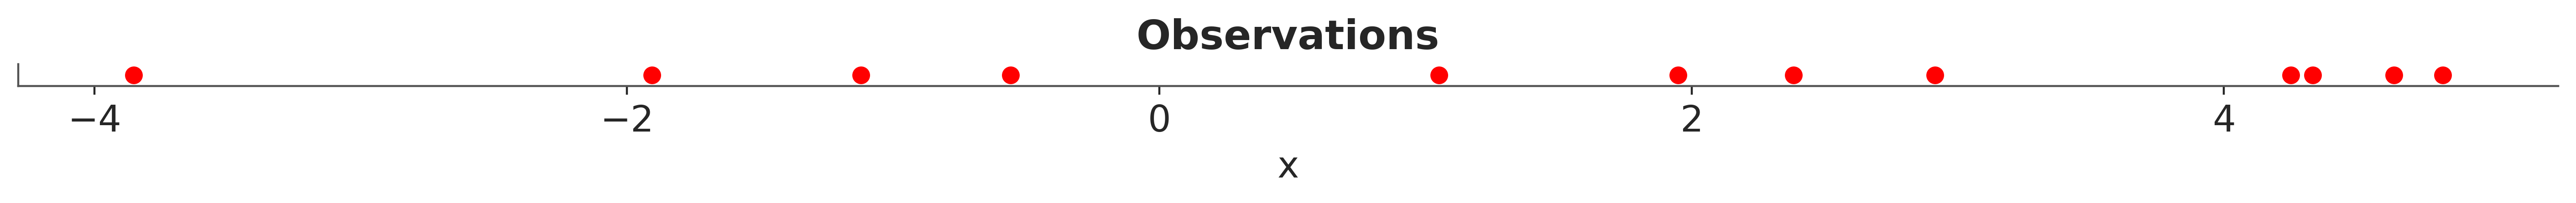

In [3]:
true_mu = 2.0
true_sigma = 3.0
n = 12

x = rng.normal(loc=true_mu, scale=true_sigma, size=n)

fig, ax = plt.subplots(figsize=(14, 1))
ax.plot(x, np.zeros_like(x), "ro")
ax.set(yticklabels=[], yticks=[], xlabel="x", title="Observations");

## Sampling from the prior and posterior

Now we'll build our simple model. Again, the focus here is not on the model of the data as such, but simply obtaining a meaningful prior and posterior distribution. We'll ask for more MCMC samples than we normally do, so that we can get a more accurate approximation of the prior and posterior distributions.

In [4]:
with pm.Model() as model:
    # priors
    mu = pm.Normal("mu", mu=0, sigma=2)
    sigma = pm.Gamma("sigma", alpha=2, beta=1)
    # likelihood
    pm.Normal("y", mu=mu, sigma=sigma, observed=x)
    # sample
    idata = pm.sample_prior_predictive(draws=10_000)
    idata.update(pm.sample(draws=10_000))

Sampling: [mu, sigma, y]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 17 seconds.


We didn't get any warnings from the sampling processes.

It is good practice to visualise the posterior distribution, so below we'll look at the joint posterior over $\mu$ and $\sigma$ parameters. Everything looks fine here.

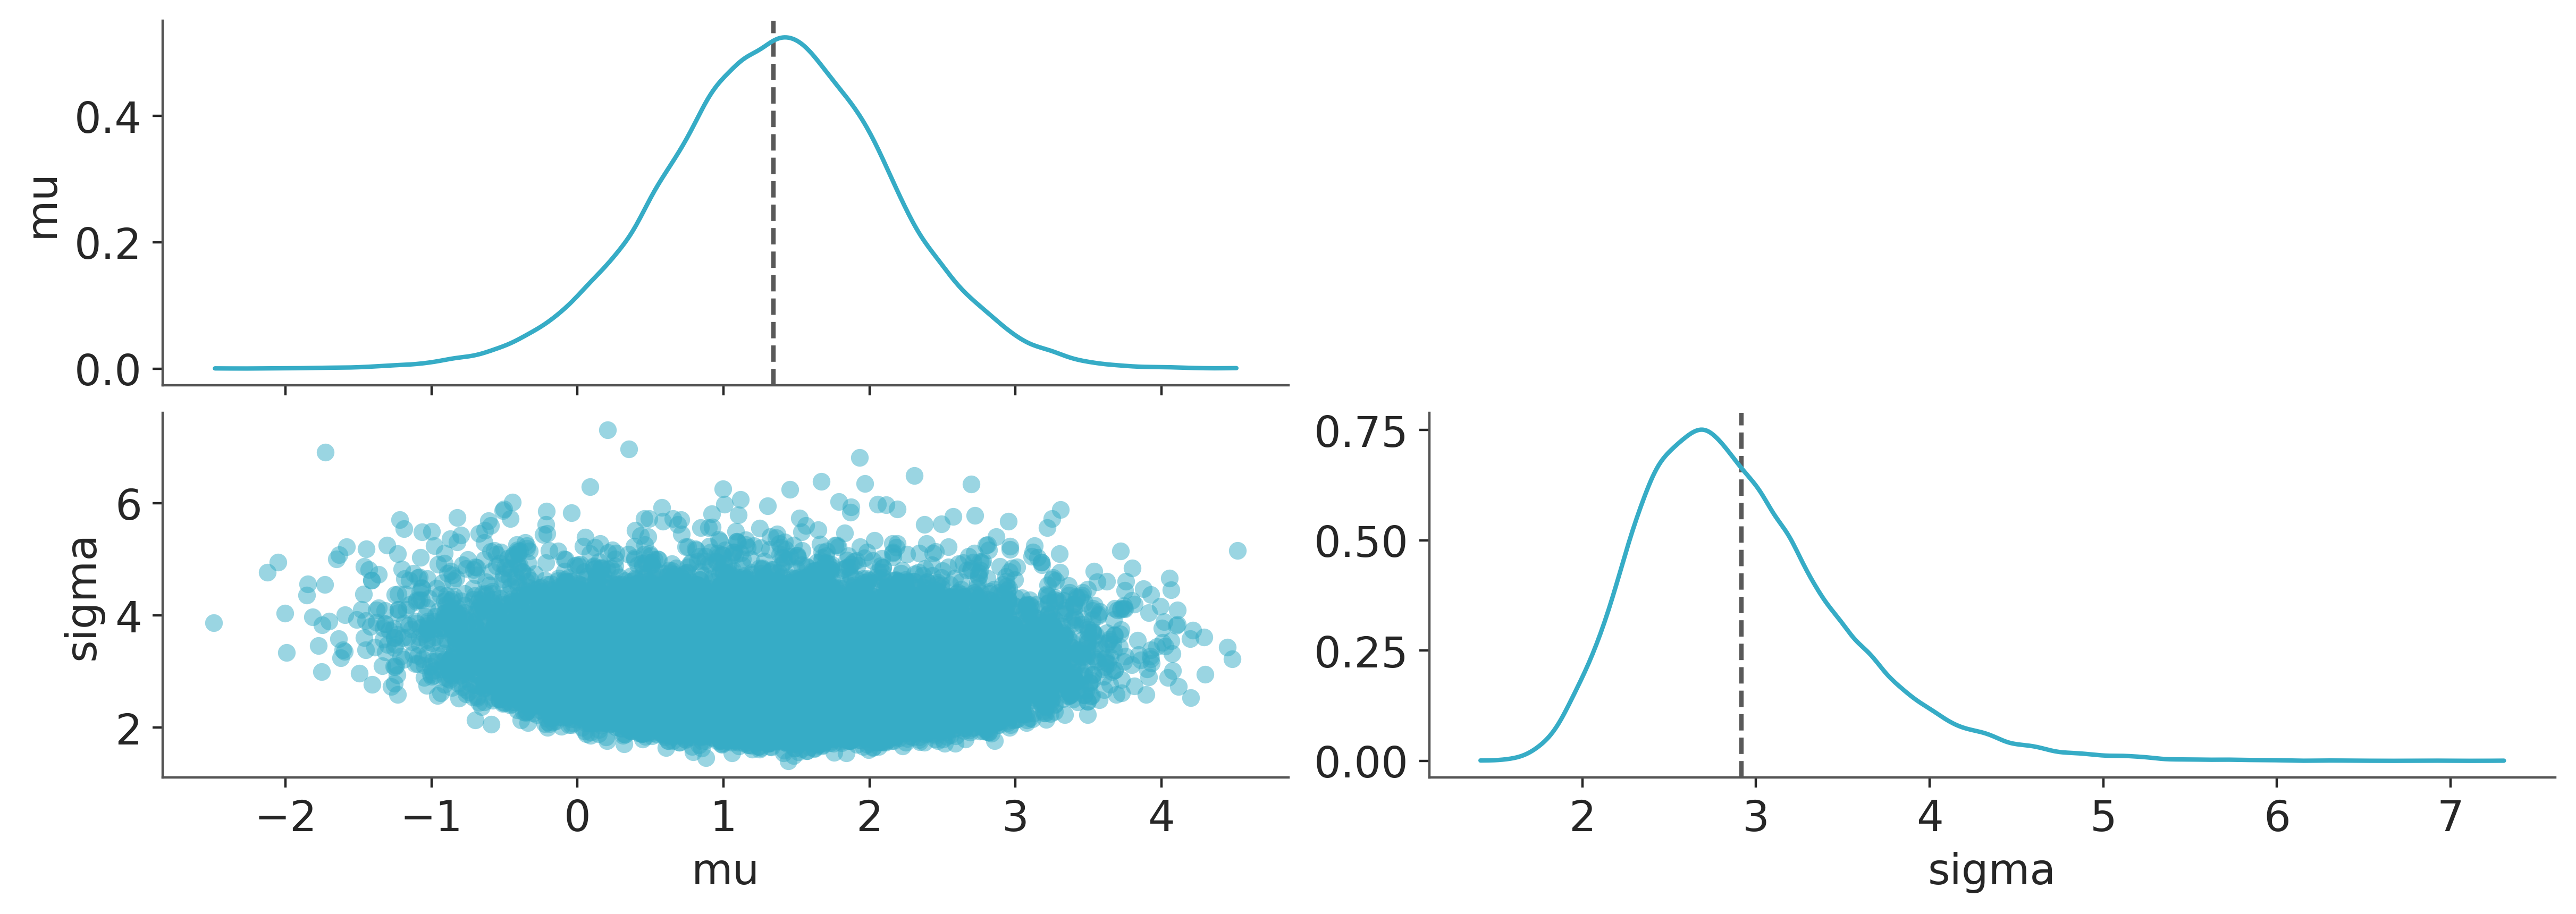

In [5]:
pc = az.plot_pair(idata, var_names=["mu", "sigma"])
az.add_lines(
    pc, {"mu": idata.posterior["mu"].mean().item(), "sigma": idata.posterior["sigma"].mean().item()}
);

Finally, seeing as $\mu$ is the core parameter of interest, we'll visualise both the prior and posterior distributions for $\mu$.

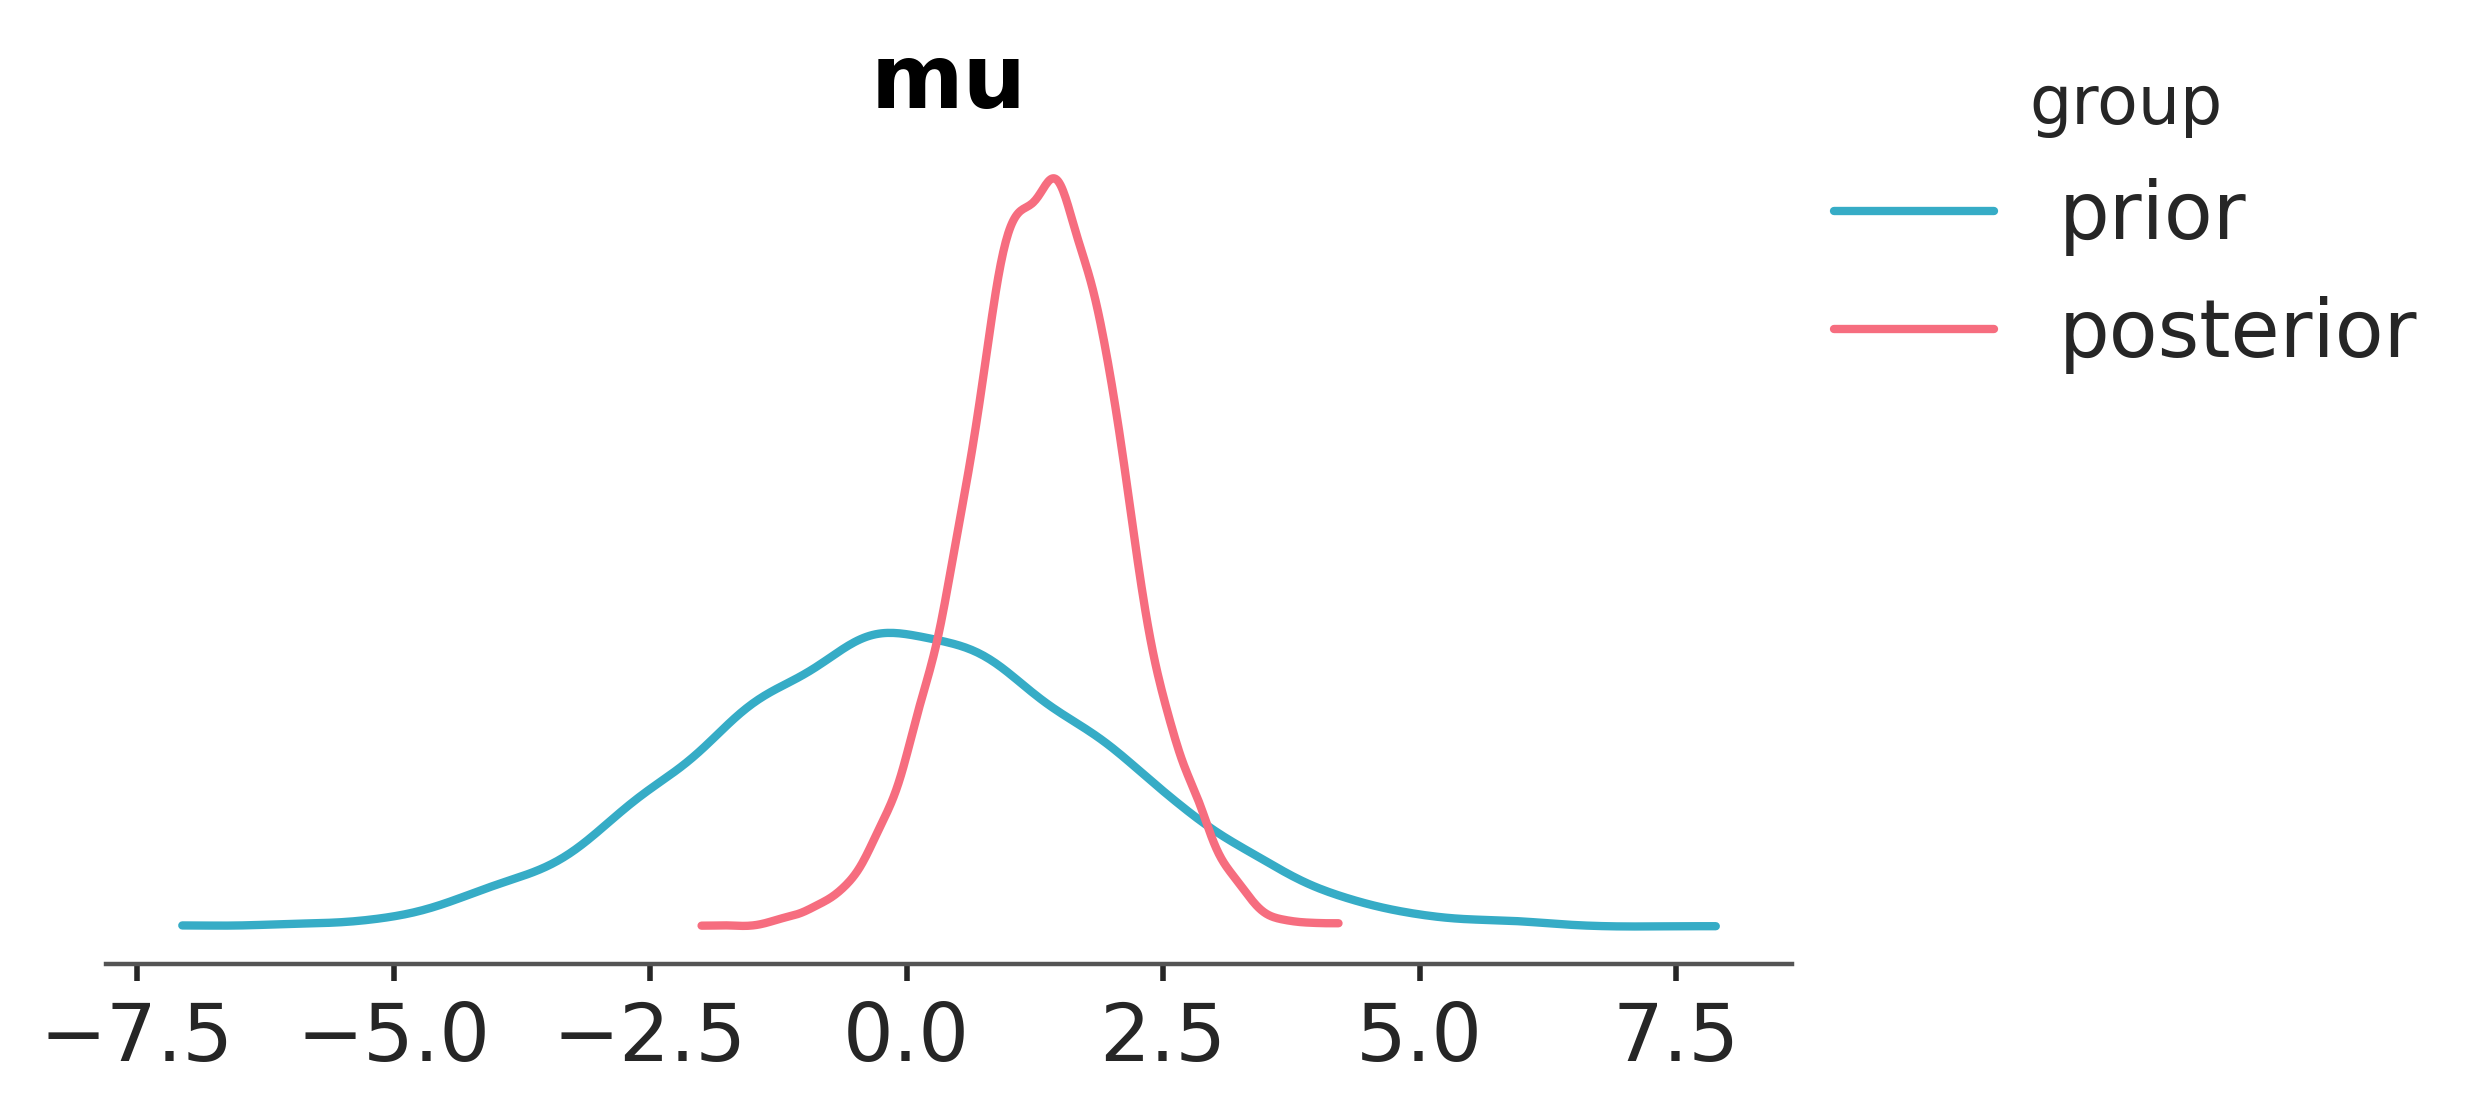

In [6]:
az.plot_prior_posterior(idata, var_names="mu");

## Bayesian hypothesis testing methods

### Posterior probability statements

The simplest form of hypothesis testing is to ask whether the mean is greater than zero. This is equivalent to asking whether the probability that $\mu$ is greater than zero is greater than 0.5. We can compute this directly from the samples. So computing compute $P(\mu>0 | x)$ is as simple as counting the number of samples where $\mu>0$ and dividing by the total number of samples - equivalent to computing the mean of the samples where $\mu>0$.

In [7]:
mu_samples = idata.posterior["mu"].values
p_mu_greater_0 = np.mean(mu_samples > 0)
p_mu_greater_0

np.float64(0.9527)

We can also include such information in a visual plot using `az.plot_posterior`.

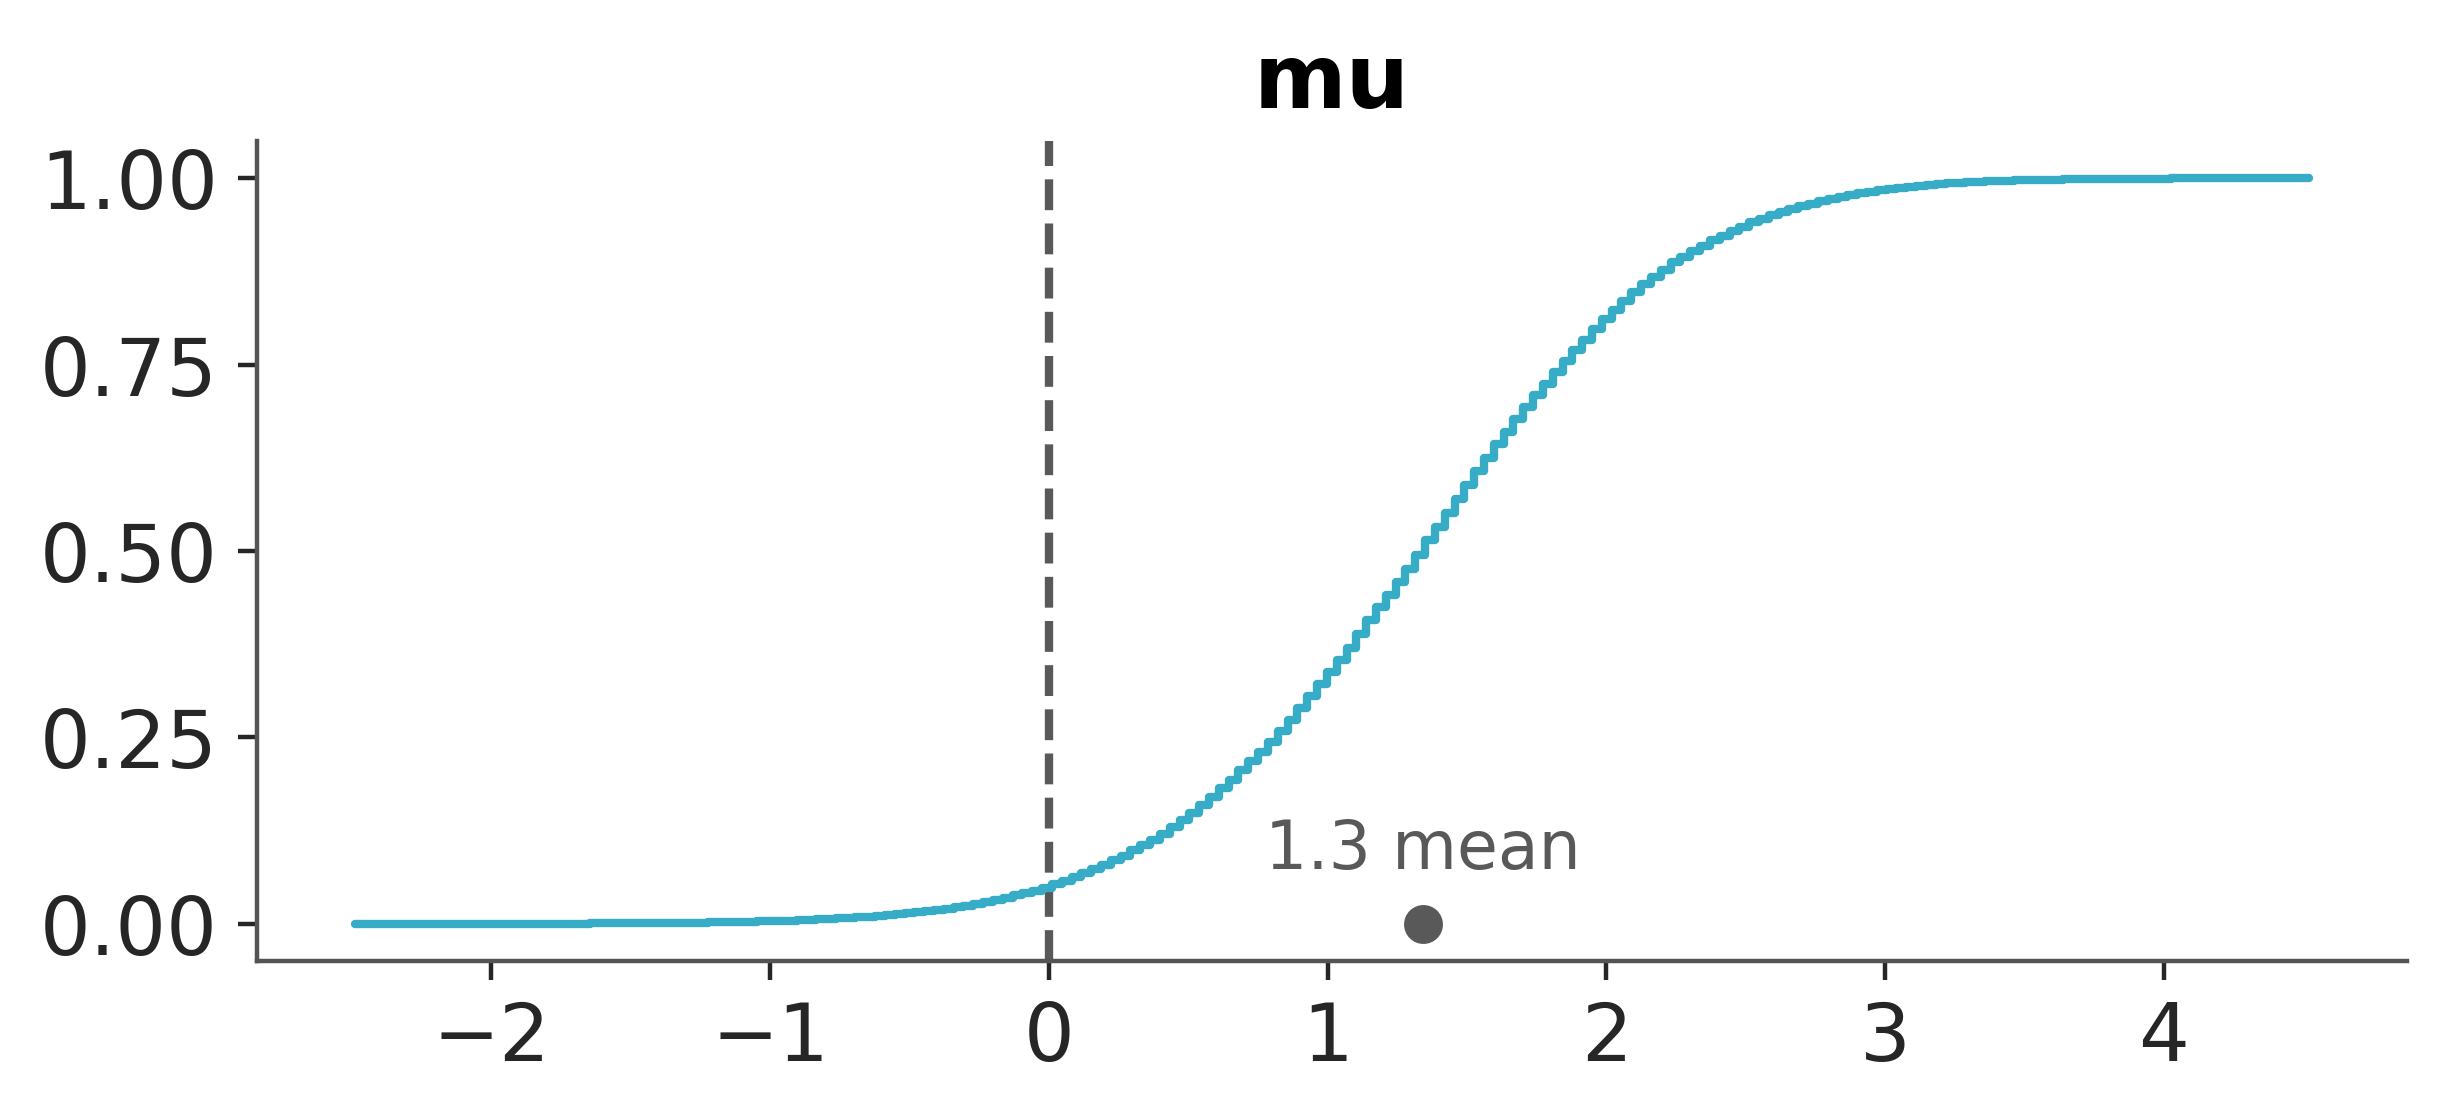

In [8]:
pc = az.plot_dist(idata, var_names=["mu"], kind="ecdf", visuals={"credible_interval": False})
az.add_lines(pc, 0);

It could also be that we have some kind of minimum meaningful threshold that we care about. For example, we might care about whether the mean is greater than 0.1. We can compute this in the same way.

In [9]:
p_mu_greater = np.mean(mu_samples > 0.1)
p_mu_greater

np.float64(0.94)

### Highest Density Intervals (HDIs)

We can define an infinite number of intervals that contain a given probability mass (e.g., 95%). However, some intervals are more informative than others. The Highest Density Interval (HDI) is the narrowest interval that contains a given probability mass. This means that every point inside the HDI has a higher probability density than any point outside the HDI. If zero is outside the HDI, it’s unlikely the parameter is near zero.

In [10]:
hdi_mu = az.hdi(idata.posterior["mu"]).values
hdi_mu.round(2)

array([-0.22,  2.9 ])

In this case, zero is within the HDI, so based on this measure, we can't express much confidence that the mean is different from zero.

Again, we can use `az.plot_posterior` to visualize the HDIs.

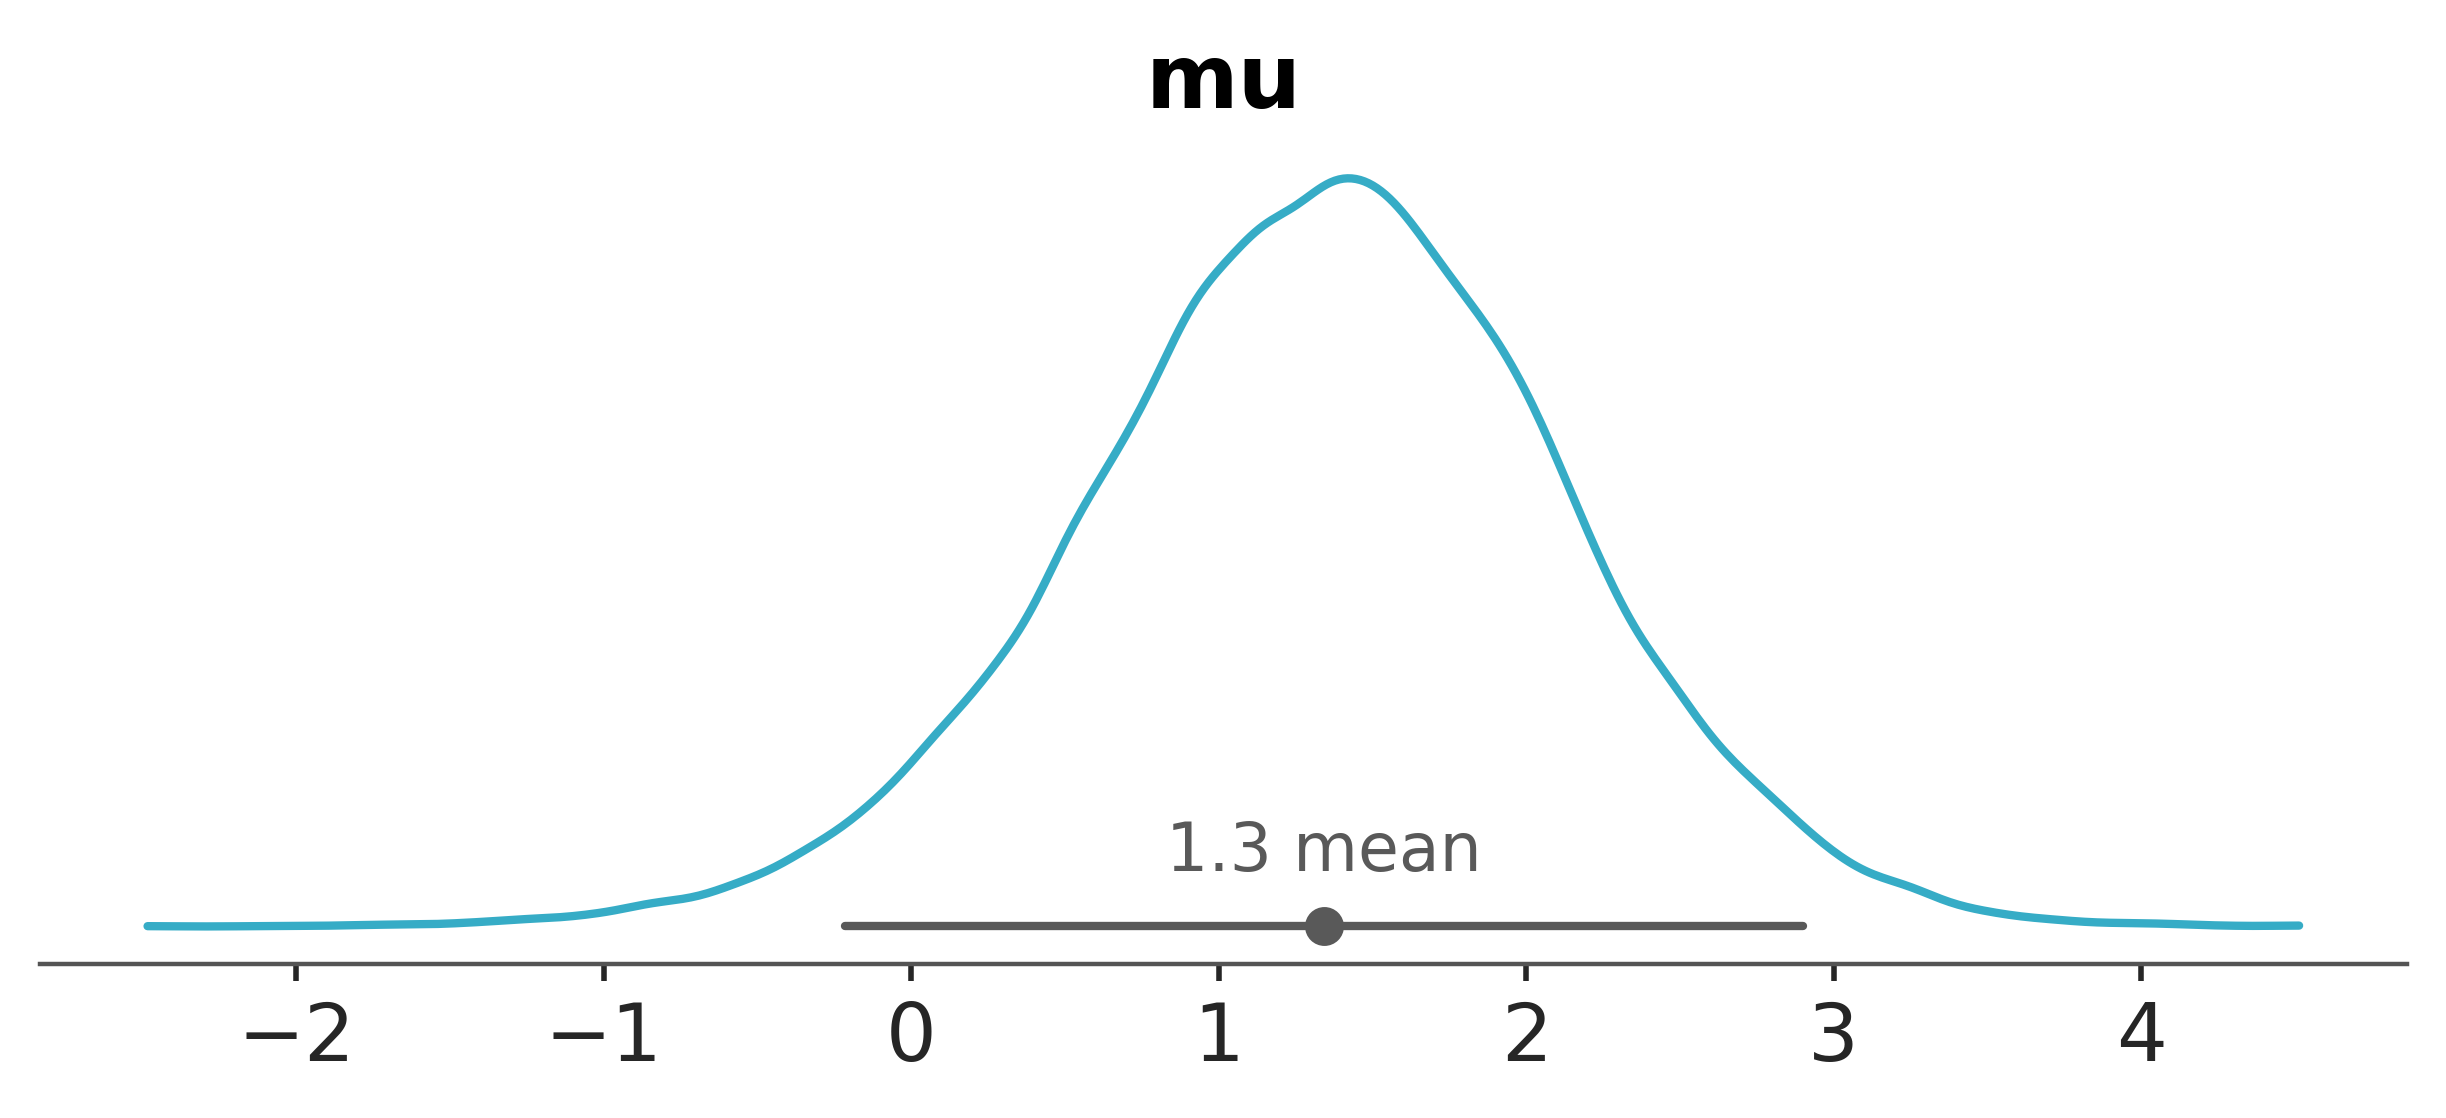

In [11]:
az.plot_dist(idata, var_names="mu");

### Region of Practical Equivalence (ROPE)

If the probability that the parameter is within a certain range is high, we can say that the parameter is practically equivalent to that value. This is a useful way to express that we don't care about small differences. 

For example, if we state that values within $-0.1$ to $0.1$ (this region need not be symmetric) are practically equivalent to zero, we can compute the probability that $\mu$ is within this range. If this probability is high enough then we can say that the mean is practically equivalent to zero.

In [12]:
az.ci_in_rope(idata, var_names="mu", rope=[-0.1, 0.1])

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    mu       float64 8B 2.374
Attributes:
    created_at:                 2026-04-25T13:50:09.663277+00:00
    creation_library:           ArviZ
    creation_library_version:   1.1.1dev0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  5.28.0+58.gf58491a3
    sample_dims:                ['chain', 'draw']
    sampling_time:              17.06807279586792
    tuning_steps:               1000

So there is only a 2.2% probability that the mean is practically equivalent to zero. This is sufficiently low that we can reject the hypothesis that the mean is practically equivalent to zero.

Third time in a row, `arviz` has our back and can plot the ROPE and HDIs.

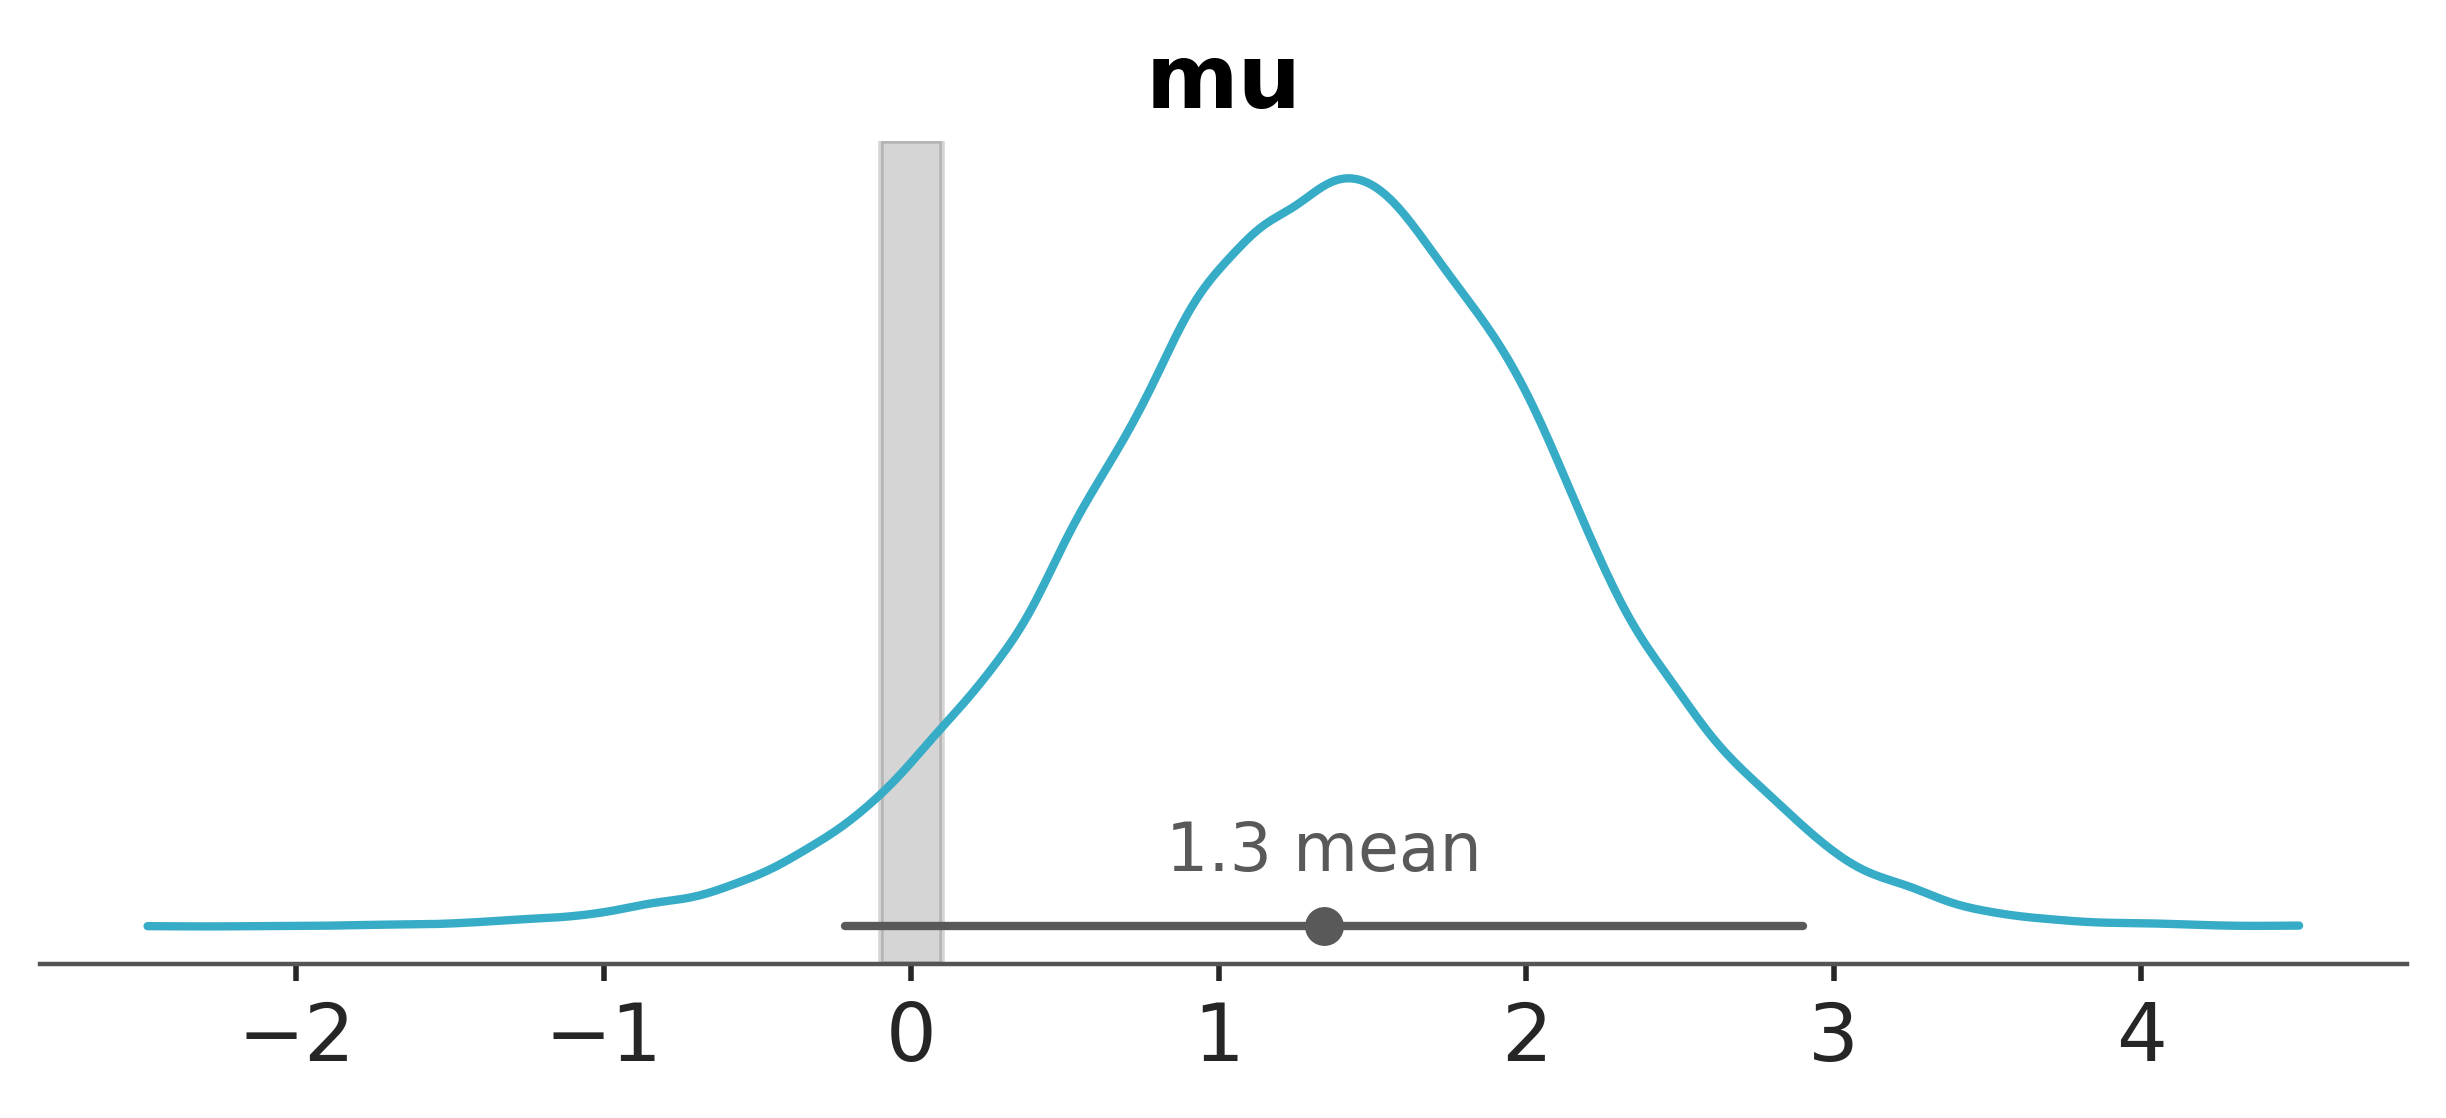

In [13]:
pc = az.plot_dist(idata, var_names=["mu"])
az.add_bands(pc, [(-0.1, 0.1)]);

The intuition we can get from this is that if the ROPE is narrow, we would require quite a high level of precision to accept the null hypthesis. The posterior distribution would have to be very tightly centered around the null value to have a large probability of being within the ROPE.

### HDI+ROPE decision criteria

{cite:t}`kruschke2018rejecting` outlines the HDI+ROPE decision rule, which is summarised in the figure taken from that paper. Namely:

* **Accept the null value**: If the HDI falls entirely within the ROPE. The HDI does not need to include the null value.
* **Reject the null value**: If the HDI falls entirely outside the ROPE. 
* **Remain undecided**: If the HDI is partially or fully outside the ROPE.

In our case, looking back at our posterior + ROPE plot above, we would remain undecided because the HDI does not fall entirely outside nor within the ROPE.

![](hdi_plus_rope_decision_rule.png)

### Bayes Factors

[Bayes Factors](https://en.wikipedia.org/wiki/Bayes_factor) provide a Bayesian alternative to classical hypothesis tests, allowing you to weigh evidence for one hypothesis relative to another. In the simplest case—testing whether $\mu=0$ versus $\mu \neq 0$ — the Bayes Factor (BF) tells you how much more (or less) likely your observed data are under the model where $\mu=0$ than under the model where $\mu$ is free to vary.

Intuitively, the Bayes Factor can be understood by comparing the density of $\mu$ at zero before and after observing the data. Before collecting data, you have a prior belief about $\mu$. This prior density at $\mu=0$ represents how plausible zero was considered initially. After seeing the data, you update these beliefs to get the posterior distribution. The posterior density at $\mu=0$ indicates how plausible zero remains given the evidence. The ratio of these densities—the Savage-Dickey ratio—is closely related to the Bayes Factor. If the data make 
$\mu=0$ more plausible relative to your initial belief, the Bayes Factor will favor  $\mu=0$. If the data diminish the credibility of $\mu=0$, the Bayes Factor will favor $\mu\neq0$

Because the Bayes Factor directly compares how the data update the prior odds of each hypothesis, the choice of prior is crucial. A strong prior concentration at $\mu=0$ could make it harder for data to move the posterior density away from zero, influencing the resulting Bayes Factor. On the other hand, a diffuse prior might make it easier for data to shift your beliefs about $\mu$. Thus, specifying a reasonable and justifiable prior distribution is essential when using Bayes Factors for hypothesis testing.

Yet again, `arviz` has a function to help us here. We can use `plot_bf` to compute the Bayes Factor for the hypothesis that $\mu=0$ versus $\mu\neq0$.

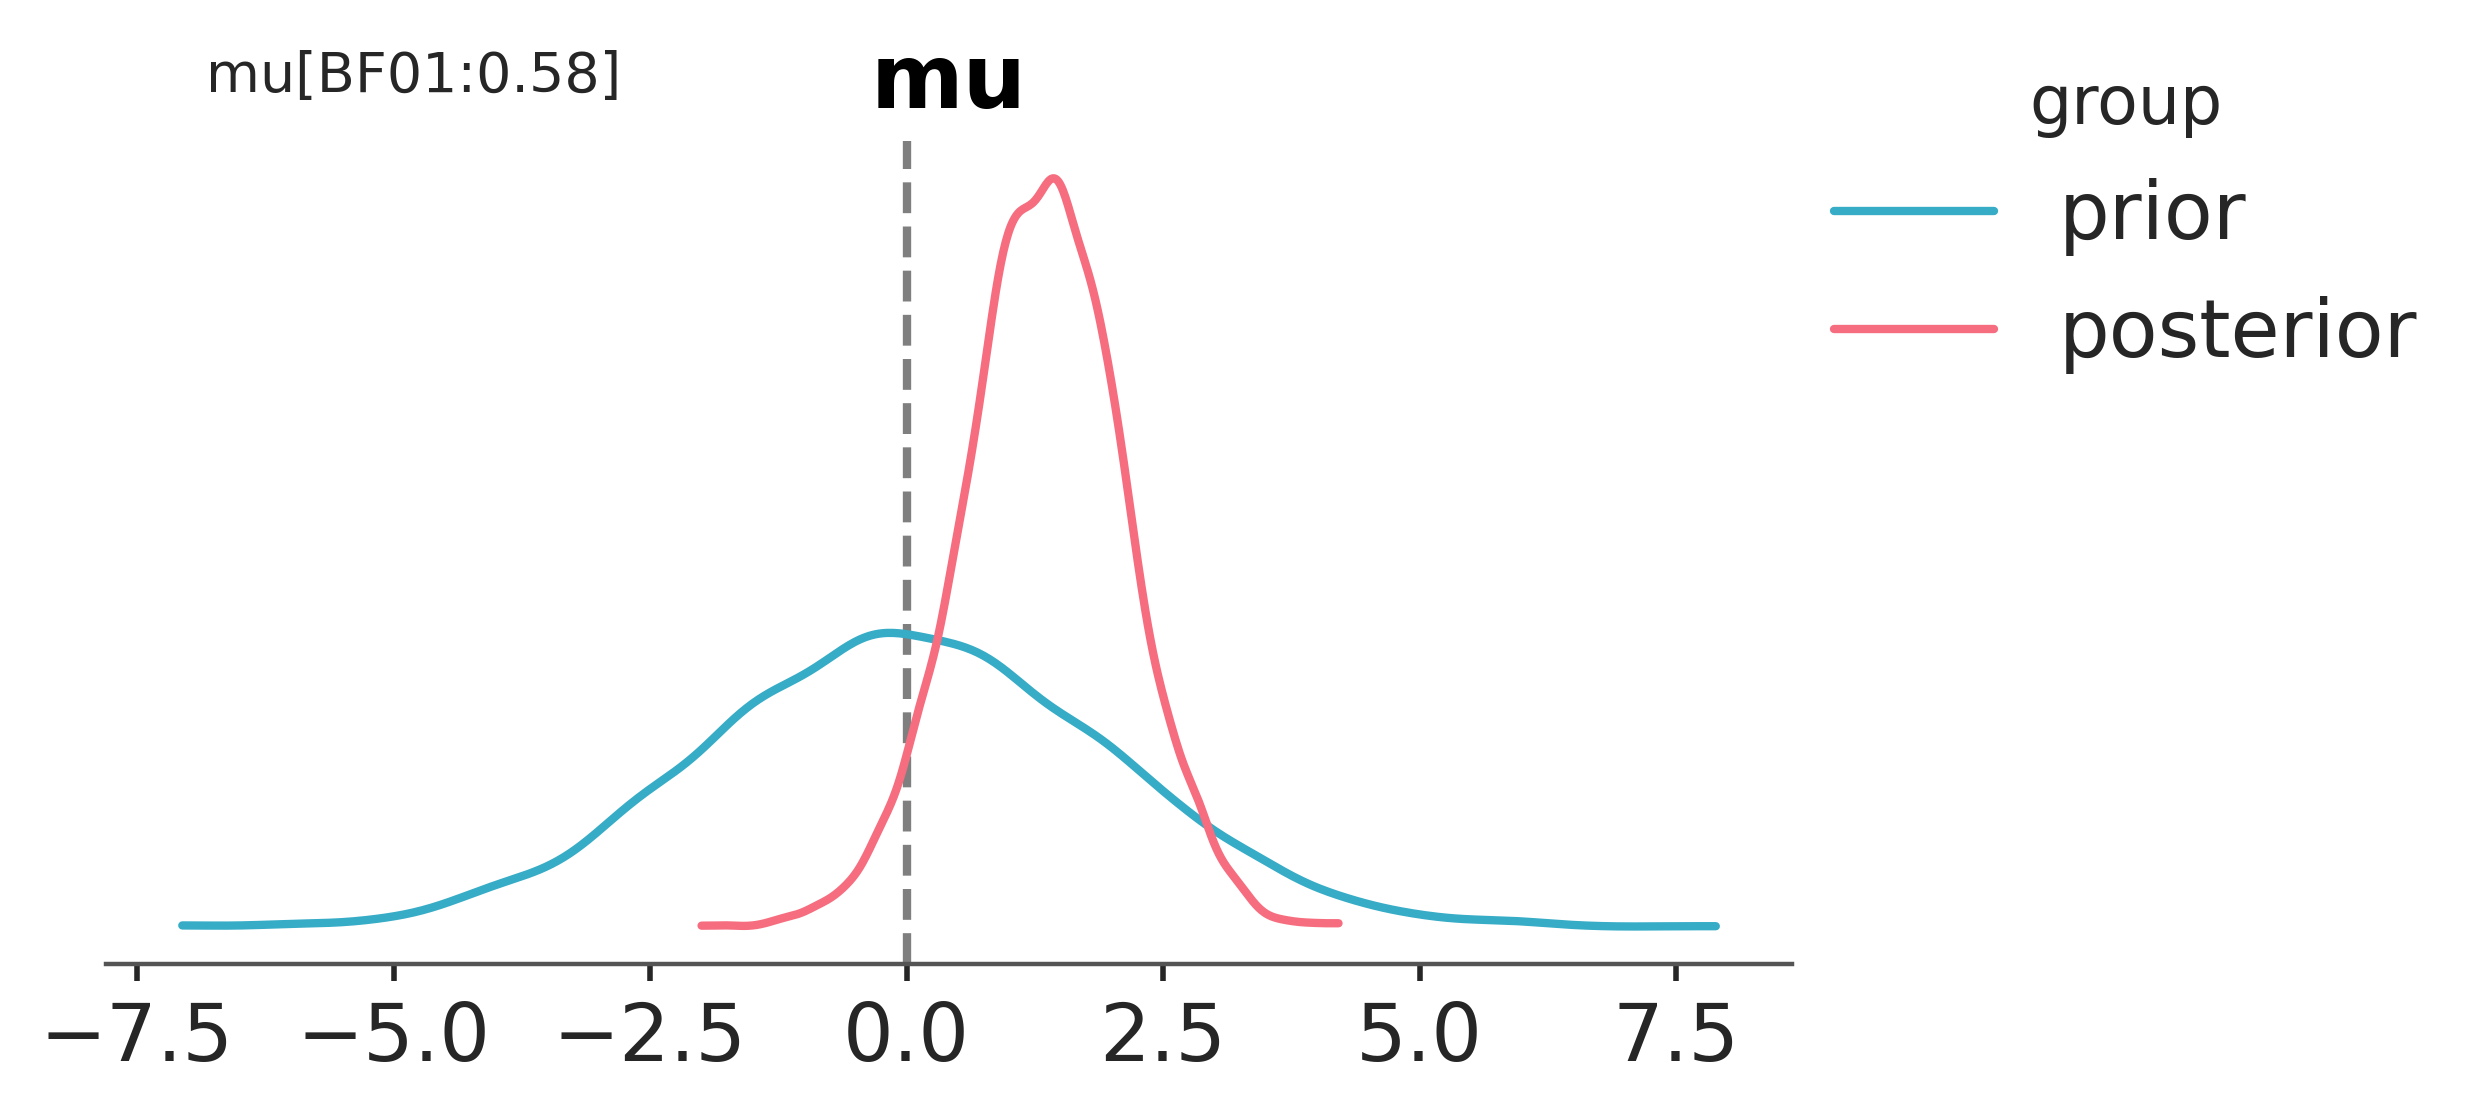

In [14]:
az.plot_bf(idata, var_names="mu", ref_val=0);

We can see that the probability of $\mu=0$ has gone _down_ after observing the data. This is reflected in the value of $BF_{01}=0.54$ in that it is less than 1.

Readers are referred to {ref}`Bayes_factor` for a more detailed look at Bayes Factors.

## Summary

**Posterior Probability Statements**  
- *Idea:* Compute $P(\theta > \delta \mid \text{data})$ directly from the posterior.  
- *Pros:* Simple, intuitive, no special tools needed.  
- *Cons:* Requires choosing a threshold $\delta$.

**Highest Density Intervals (HDIs)**  
- *Idea:* Identify the range of values containing a fixed portion (e.g., 95%) of the posterior mass.  
- *Pros:* Provides a clear summary of where the parameter lies; easy to interpret.  
- *Cons:* By itself, doesn’t encode a decision rule; must still choose what HDI exclusion implies.

**ROPE (Region of Practical Equivalence)**  
- *Idea:* Define a small interval around the null (e.g., zero) representing negligible effect size and assess posterior mass within it.  
- *Pros:* Focuses on practical rather than just statistical significance; flexible.  
- *Cons:* Requires subjective definition of what counts as negligible.

**ROPE + HDI Decision Rule**  
- *Idea:* Combine ROPE with HDI to classify results as negligible, meaningful, or inconclusive.  
- *Pros:* Offers a three-way decision with practical interpretation; balances interval uncertainty and practical thresholds.  
- *Cons:* Still needs careful definition of ROPE bounds and HDI level.

**Bayes Factors**  
- *Idea:* Compare evidence for one model/hypothesis against another by ratio of marginal likelihoods.  
- *Pros:* Provides a direct measure of relative evidence; can be viewed as updating prior odds.  
- *Cons:* Sensitive to priors; can be computationally challenging; interpreting BF scales can be tricky.

## Authors
* Authored by [Benjamin T. Vincent](https://github.com/drbenvincent) in December, 2024.
* Updated by [Osvaldo Martin](https://aloctavodia.github.io/) in Dec, 2025.
* Updated by [Osvaldo Martin](https://aloctavodia.github.io/) in Apr, 2026.

## References
:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Sat, 25 Apr 2026

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.12.0

pytensor: 2.38.0+133.g80cc113b5
xarray  : 2026.4.0

arviz     : 1.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pymc      : 5.28.0+58.gf58491a3

Watermark: 2.6.0



:::{include} ../page_footer.md
:::